# 1. Torch utilities

In [1]:
import os 
import torch
import torch.distributions as tdist
from torch.utils.dlpack import to_dlpack
from torch.utils.dlpack import from_dlpack
rnorm = tdist.Normal(torch.tensor([0.]), torch.tensor([1]))
from torch.autograd import Function
import numpy as np
from sksparse.cholmod import cholesky
import scipy.sparse as scsp
from math import sqrt 
from torch_sparse.tensor import SparseTensor
from torch_sparse.matmul import matmul as matmul2
import cupy
from cupyx.scipy.sparse.linalg import spsolve as cupy_spsolve
from cupyx.scipy.sparse import csc_matrix as cupy_sp_csc_matrix
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from IPython.display import Image
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Scipy_SolveCholesky(Function):

# Cholesky decomposition of sparse matrices

    @staticmethod
    def forward(self, torch_sparsematrix, dt, perm=False):
        # cast torch_sparsematrix to scipy sparse csc matrix 
        sp_sparsematrix = scsp.csc_matrix((torch_sparsematrix.detach().cpu().coalesce().values(),
                                           torch_sparsematrix.detach().cpu().coalesce().indices()),
                                          shape=(torch_sparsematrix.shape[0],torch_sparsematrix.shape[0]))

        A = scsp.identity(sp_sparsematrix.shape[0])+\
            (dt* sp_sparsematrix) 
        
        # Cholesky decomposition with permutation A=P'LL'P
        if perm==True:
            AspChol = cholesky(A)
            # save input requires for backward (A here from Ax=b) and
            self.save_for_backward( torch.tensor(AspChol.P()), torch.tensor(AspChol.L()) )
        else:
            # Cholesky decomposition without permutation A=L'L
            AspChol = cholesky(A,ordering_method="natural")
            # save input requires for backward (A here from Ax=b) and
            Lcoo = AspChol.L().tocoo()
            L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),
                                                torch.FloatTensor(Lcoo.data))
            self.save_for_backward(L)

        return torch.as_tensor(L, dtype=torch_sparsematrix.dtype)
    
def sparse_eye(size, val = torch.tensor(1.0)):
    """
    Returns the identity matrix as a sparse matrix
    """
    indices = torch.arange(0, size).long().unsqueeze(0).expand(2, size)
    if len(val.size())==0:
        values = (val.expand(size))
    else:
        values = val.to(device)
    cls = getattr(torch.sparse, values.type().split(".")[-1])
    return cls(indices, values, torch.Size([size, size]))

def sparse_repeat(size,n1,n2):
    """
    Returns a sparse zero-filled tensor repeating 
    a 2D size*size sparse zero-filled tensor
    n1 times along dim1 and n2 times along n2
    """
    return torch.sparse.FloatTensor(size*n1,size*n2)

def spspmm(A,B):
    """Matrix product of two sparse tensors. Both input sparse matrices need to
    be coalesced (use the :obj:`coalesced` attribute to force).
    Args:
        indexA (:class:`LongTensor`): The index tensor of first sparse matrix.
        valueA (:class:`Tensor`): The value tensor of first sparse matrix.
        indexB (:class:`LongTensor`): The index tensor of second sparse matrix.
        valueB (:class:`Tensor`): The value tensor of second sparse matrix.
        m (int): The first dimension of first corresponding dense matrix.
        k (int): The second dimension of first corresponding dense matrix and
            first dimension of second corresponding dense matrix.
        n (int): The second dimension of second corresponding dense matrix.
        coalesced (bool, optional): If set to :obj:`True`, will coalesce both
            input sparse matrices. (default: :obj:`False`)
    :rtype: (:class:`LongTensor`, :class:`Tensor`)
    """

    indexA = A.detach().cpu().coalesce().indices()
    valueA = A.detach().cpu().coalesce().values()
    indexB = B.detach().cpu().coalesce().indices()
    valueB = B.detach().cpu().coalesce().values()
    m = A.size()[0]
    k = A.size()[1]
    n = B.size()[1]

    coalesced =True

    A2 = SparseTensor(row=indexA[0], col=indexA[1], value=valueA,
                     sparse_sizes=(m, k), is_sorted=not coalesced)
    B2 = SparseTensor(row=indexB[0], col=indexB[1], value=valueB,
                     sparse_sizes=(k, n), is_sorted=not coalesced)
    
    C = matmul2(A2, B2)
    row, col, value = C.coo()
    indexC = torch.stack([row, col], dim=0)
    valueC = value

    return torch.sparse.FloatTensor(indexC.long(), valueC, torch.Size([m,n]))

def pow_diff_operator(A,pow):
    B = A
    if pow>1:
      for _ in range(pow-1):
        B = spspmm(B,A)  
    return B

# 2. SPDE-based spatio-temporal simulation

Let now consider the spatio-temporal extension to perform non-conditional simulations of a
random field $\mathbf{x}$ solution of the spatio-temporal SPDE:
\begin{eqnarray}
\label{isotropic_SPDE_st}
\frac{\partial{\mathbf{X}}}{\partial{t}}+(\kappa^2(\mathbf{s},t)-\Delta)^{\alpha/2} \mathbf{X}(\mathbf{s},t)=\tau \mathbf{Z}(\mathbf{s},t)
\end{eqnarray}

To ensure more regularity it is also possible to consider the noise process $\mathbf{Z}$ be white in time but with spatial dependence, such as a solution to an isotropic spatial SPDE for instance:
\begin{align*}
& \mathbf{Z}(\mathbf{s},t) = \mathbf{Z}_T(t) \otimes  \mathbf{W}_S(\mathbf{s})
\end{align*}
with
\begin{align}
\label{isotropic_spatial_SPDE}
& (\kappa_S^2 - \Delta)^{\alpha_S/2} \mathbf{W}_S(\mathbf{s}) = \mathbf{Z}_S(\mathbf{s})
\end{align}

This lead to the final model:
\begin{eqnarray}
\label{isotropic_SPDE_st_2}
\frac{\partial{\mathbf{X}}}{\partial{t}}+(\kappa^2(\mathbf{s},t)-\Delta)^{\alpha/2} \mathbf{X}(\mathbf{s},t)=\tau \mathbf{Z}_T(t) \otimes  \mathbf{W}_S(\mathbf{s})
\end{eqnarray}

We use a numerical implicit Euler scheme to discretize the space-time SPDE:
\begin{eqnarray*}
\frac{\mathbf{x}_{t+dt}-\mathbf{x}_{t}}{dt}+\mathbf{B}\mathbf{x}_{t+dt}=\frac{\tau}{\sqrt{dt}} \mathbf{w}_{t+dt}
\end{eqnarray*} 

where

* $\mathbf{x}_{t}$ the state space at time $t$
* $\mathbf{B}$ is still the discrete differential operator $(\kappa^2-\Delta)^{\alpha/2}$ 
* The random vectors $\lbrace \mathbf{w}_t$, $t>0 \rbrace$ are independent realizations of $\mathbf{W}_S$ the solution of a spatial isotropic SPDE

Let now develop the relation between $\mathbf{x}_{t+dt}$ using $\mathbf{x}_{t}$ and $\mathbf{z}_{t+dt}$ :
\begin{align}
\label{implicit_scheme}
& \frac{\mathbf{x}_{t+dt}-\mathbf{x}_{t}}{dt}+\mathbf{B}_{t+dt}\mathbf{x}_{t+dt}&=&\frac{\tau}{\sqrt{dt}} \mathbf{w}_{t+dt} \nonumber \\
& \mathbf{x}_{t+dt}-\mathbf{x}_{t} + dt\mathbf{B}_{t+dt}\mathbf{x}_{t+dt}&=&\tau\sqrt{dt} \mathbf{w}_{t+dt} \nonumber  \\
& (\mathbf{I}+dt\mathbf{B}_{t+dt})\mathbf{x}_{t+dt}&=&\mathbf{x}_{t}+\tau\sqrt{dt}\mathbf{w}_{t+dt} \nonumber  \\
& \mathbf{x}_{t+dt} &=&(\mathbf{I}+dt\mathbf{B}_{t+dt})^{-1}(\mathbf{x}_{t}+\tau\sqrt{dt}\mathbf{w}_{t+dt}) \nonumber  \\
& \mathbf{x}_{t+dt} &=& \mathbf{M}_{t+dt}(\mathbf{x}_{t}+\tau \sqrt{dt} \mathbf{w}_{t+dt}) &
\end{align}

From now on, let denote $\mathbf{M}_{t+dt}=(\mathbf{I}+dt\mathbf{B}_{t+dt})^{-1}$ the matrix operator to emulate the dynamical evolution of state $\mathbf{x}$ from time $t$ to $t+dt$. It will ease the link with formal data assimilation state space formulation.

## 2.1 Global anisotropy

The Laplacian operator $\Delta$ is invariant to translations and
rotations. As a consequence, we will get an isotropic space-time field. Then, let introduce some diffusion process through a local diffusion operator $\mathbf{H}(\mathbf{s},t)$ in the SPDE. In the case of global anisotropy, $\mathbf{H}$ is constant over space and time:

\begin{eqnarray*}
(\kappa^2-\nabla \cdot \mathbf{H}\nabla)^{\frac{\alpha}{2}}\mathbf{X}(\mathbf{s},t)=\tau\mathbf{Z}(\mathbf{s},t)
\end{eqnarray*}

/tmp/ipykernel_2502725/2997379416.py:53: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:653.)
  return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))


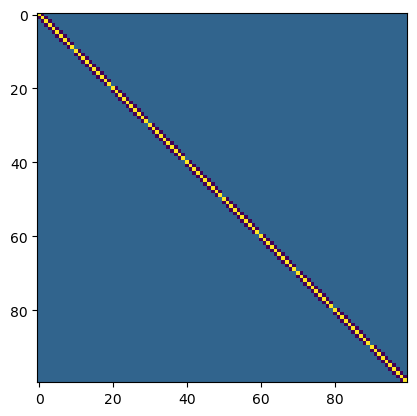

In [2]:
def diff_operator(nx, ny, dx, dy, H, kappa):

    nb_nodes = nx*ny
    H11=H[0,0] ; H12=H[0,1] ; H21=H[1,0] ; H22=H[0,1]  
    
    index = torch.arange(0,nb_nodes)
    ## Right neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 0)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k1 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + 1, (-1*H11/(dx**2)).repeat_interleave(N) ))
    ## Left neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 1)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k2 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - 1, (-1*H11/(dx**2)).repeat_interleave(N) ))
    ## Top neighbours
    index_sel = torch.where((index+1) <= (ny-1)*nx )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k3 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx, (-1*H22/(dx**2)).repeat_interleave(N) ))
    ## Bottom neighbours
    index_sel = torch.where((index+1) >= (nx+1) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k4 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx, (-1*H22/(dx**2)).repeat_interleave(N) ))
    ## Top-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k5 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx+1, ((H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Top-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k6 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx-1, (-1*(H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Bottom-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k7 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx+1, (-1*(H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Bottom-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k8 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx-1, ((H12+H21)/(4*dx*dy)).repeat_interleave(N) ))
    ## Central point
    N=len(index)
    k9 = torch.stack((index.float(), index.float(), (kappa**2 + 2*(H11/(dx**2) + H22/(dy**2))).repeat_interleave(N) ))
    ## Stack all neighbours
    k = torch.cat((k1, k2, k3, k4, k5, k6, k7, k8, k9),dim=1)
    ## Create sparseMatrix
    return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))

# Example
A = diff_operator(10,10,1,1,H=torch.tensor(np.array([[1,0],[0,1]])),kappa=1/3)
plt.imshow(A.to_dense().numpy())

##  2.2 Parameters of the simulation

In [2]:
# Domain size
resolution=10
nx = int(12.8*resolution)
ny = int(12.8*resolution)
nb_nodes = nx*ny
# x, y and time lag
dx = 1
dy = 1
dt = 0.25
# kappa
kappa = 1/3
pow = 1
# Simulation total time
tps = 100
n_iter = int(tps/dt)
n_iter = 500

## 2.3 Cholesky decomposition

In [6]:
A = diff_operator(nx,ny,dx,dy,torch.tensor(np.array([[1,1],[1,1]])),kappa)
B = pow_diff_operator(A,pow)
# Cholesky decomposition of (I+dtB)
L = Scipy_SolveCholesky.apply(B,dt)
Achol = torch.tensor(np.dot(L.to_dense().numpy(),np.transpose(L.to_dense().numpy())))

/tmp/ipykernel_820984/3836502537.py:49: UserWarning: torch.sparse.SparseTensor(indices, values, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:641.)
  L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),


## 2.4 Run a simulation

In [7]:

# Initialisation  
x = [torch.randn(nb_nodes)]

def run_simulation(i,x):
  #### Calcul du second membre
  noise = torch.flatten(sqrt(dt/(dx*dy))*rnorm.sample((nb_nodes,)))+torch.flatten(x[i])
  tmp = torch.triangular_solve(torch.unsqueeze(torch.unsqueeze(noise,dim=1),dim=0).float(),
                              torch.tril(torch.unsqueeze(L.to_dense(),dim=0)).float(),
                              upper=False)
  xi = torch.triangular_solve(tmp[0],
                             torch.transpose(torch.tril(torch.unsqueeze(L.to_dense(),dim=0)).float(),1,2),
                             upper=True)
  xi = torch.flatten(xi[0])
  x.append(xi)
  plt.imshow(xi.numpy().reshape(nx,ny),vmin=-2,vmax=2)
  return x

def build_simulation_solver(L_sparse):
    """
    Pré-calcule L_dense et L_dense^T à partir du facteur de Cholesky creux.
    À appeler UNE SEULE FOIS, résultat réutilisé à chaque pas de simulation.
    """
    L_d  = torch.tril(L_sparse.to_dense()).float()
    L_dT = L_d.T.contiguous()
    return L_d, L_dT


def run_simulation_fast(n_steps, L_dense, L_denseT, x0=None,
                        dt=1.0, dx=1, dy=1, nb_nodes=None,
                        device=torch.device('cpu')):
    """
    Génère n_steps pas de la simulation SPDE implicite.

    x_{t+1} = (L L^T)^{-1} (x_t + σ·ε)    où L L^T = I + dt·B

    Paramètres
    ----------
    n_steps   : nombre de pas de temps
    L_dense   : facteur L pré-calculé (nb_nodes × nb_nodes), float32
    L_denseT  : L^T contiguous, float32
    x0        : état initial (nb_nodes,), tiré aléatoirement si None
    dt, dx, dy: paramètres de la discrétisation
    nb_nodes  : taille de l'état (inféré depuis L_dense si None)
    device    : torch.device

    Retourne
    --------
    states : tensor (n_steps, nb_nodes), float32, sur CPU
    """
    if nb_nodes is None:
        nb_nodes = L_dense.shape[0]

    sigma = float(np.sqrt(dt / (dx * dy)))

    # Pré-allouer le tensor de sortie
    states = torch.empty((n_steps, nb_nodes), dtype=torch.float32)

    x_cur = (x0 if x0 is not None else torch.randn(nb_nodes)).float()

    L_d  = L_dense.to(device)
    L_dT = L_denseT.to(device)

    for i in range(n_steps):
        # Bruit blanc N(0, σ²·I)
        rhs = x_cur + sigma * torch.randn(nb_nodes, device=device)

        # Résolution Lz = rhs  (descente)
        z = torch.linalg.solve_triangular(L_d, rhs.unsqueeze(1), upper=False)
        # Résolution L^T x = z  (remontée)
        x_cur = torch.linalg.solve_triangular(L_dT, z, upper=True).squeeze(1)

        states[i] = x_cur.cpu()

    return states

def generate_obs_fast(states, nx, ny, n_iter):
    """
    Version vectorisée de generate_pseudo_obs :
    Pré-calcule tous les index d'observation pour chaque pas de temps,
    puis remplit le tensor y en une seule passe (sans plt ni boucle d'affichage).

    Retourne
    --------
    y         : tensor (n_iter, nb_nodes) avec NaN partout sauf aux obs
    index_obs : liste de n_iter arrays d'indices
    """
    nb_nodes = nx * ny
    y = torch.full((n_iter, nb_nodes), float('nan'))
    index_obs = []

    for i in range(n_iter):
        idx_list = []
        for j in range(ny):
            s1 = nx * (j - 1) + 20 + j + (20 * (i % nx))
            idx_list.extend(range(s1, s1 + 4))
            s2 = nx * (j - 1) + 20 - j - (20 * (i % nx))
            idx_list.extend(range(s2 - 4, s2))
        idx_arr = np.array(idx_list)
        valid   = np.unique(np.where((idx_arr >= 0) & (idx_arr < nb_nodes))[0])
        idx_arr = idx_arr[valid]
        index_obs.append(idx_arr)
        y[i, idx_arr] = states[i, idx_arr]

    return y, index_obs

# ── VERSION RAPIDE (×38) ──────────────────────────────────────────────────────
# Pré-calcule L_dense une seule fois, évite to_dense() à chaque pas
L_d, L_dT = build_simulation_solver(L)
x = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# filenames = []
# for i in range(n_iter):
#     plt.cla()
#     x = run_simulation(i,x)
#     filename = f'{i}.png'
#     filenames.append(filename)
#     plt.savefig(filename)
#     plt.close()
# x = torch.stack(x[1:],dim=0)

# ── GIF optionnel (désactivé par défaut — coûteux en I/O) ────────────────────
# if os.path.exists('mysimu.gif'):
#     os.remove('mysimu.gif')
# with imageio.get_writer('mysimu.gif', mode='I') as writer:
#     for filename in filenames:
#         image = imageio.imread(filename)
#         writer.append_data(image)
# for filename in set(filenames):
#     os.remove(filename)


In [6]:
Image(url='mysimu.gif')  

# 3. SPDE-based spatio-temporal kriging

## 3.1 Create a set of observations

In [8]:
def generate_pseudo_obs(i,x,y):
  index = []
  for j in range(ny):
        start = nx*(j-1)+20+j+(20*np.mod(i,nx))
        index.extend(np.arange(start, start+4))
        start = (nx*(j-1))+20-j-(20*np.mod(i,nx))
        index.extend(np.arange(start-4,start))
  index = np.array(index)
  id = np.unique(np.where( (index<(nx*ny)) & (index>=0) )[0])
  index = index[id]
  index_obs.append(index)
  y[i,index] = x[i,index]
  # save frame
  plt.imshow(y[i].numpy().reshape(nx,ny),vmin=-2,vmax=2)
  return y, index_obs

# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
# Vectorisée : pas de plt.savefig à chaque pas, pas de boucle d'affichage
y, index_obs = generate_obs_fast(x, nx, ny, n_iter)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# y = torch.empty(x.shape)
# y[:] = np.nan
# index_obs = []
# filenames = []
# for i in range(n_iter):
#   plt.cla()
#   y, index_obs = generate_pseudo_obs(i,x,y)
#   filename = f'{i}.png'
#   filenames.append(filename)
#   plt.savefig(filename)
#   plt.close()
#
# if os.path.exists('mydata.gif'):
#     os.remove('mydata.gif')
# with imageio.get_writer('mydata.gif', mode='I') as writer:
#     for filename in filenames:
#         image = imageio.imread(filename)
#         writer.append_data(image)
# for filename in set(filenames):
#     os.remove(filename)


In [8]:
Image(url='mydata.gif')  

## 3.2 General equations

Regarding optimal interpolation, let note $\mathbf{y}$ the observations, the covariance matrix of \begin{bmatrix} \mathbf{y} \\ \mathbf{x} \end{bmatrix} is:
\begin{align*}
\mathbf{\Sigma} = \begin{bmatrix} \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}} &  \mathbf{\Sigma}_{\mathbf{y}\mathbf{x}} \\ \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}  & \mathbf{\Sigma}_{\mathbf{x}\mathbf{x}} \end{bmatrix}
\end{align*}
with $\mathbf{\Sigma}_{\mathbf{y}\mathbf{x}}^\mathrm{T}=\mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}$

The OI or simple kriging (with zero mean) of $\mathbf{x}$ is given by:
\begin{align*}
\mathbf{x}^\star = \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}  \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1} \mathbf{y}
\end{align*}
Its error covariance matrix is:
\begin{align*}
\mathrm{Cov}(\mathbf{x}^\star-\mathbf{x}) = \Sigma_{\mathbf{x}\mathbf{x}} - \Sigma_{\mathbf{x}\mathbf{y}} \Sigma_{\mathbf{y}\mathbf{y}}^{-1} \Sigma_{\mathbf{y}\mathbf{x}}
\end{align*} 

We show that this formula can be rewritten:
\begin{align*}
\mathbf{x}^\star = -\mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{Q}_{\mathbf{x}\mathbf{y}} \mathbf{y}
\end{align*}
Indeed :
\begin{align*}
\mathbf{\Sigma} \mathbf{Q} =  \begin{bmatrix} \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}} &  \mathbf{\Sigma}_{\mathbf{y}\mathbf{x}} \\ \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}  & \mathbf{\Sigma}_{\mathbf{x}\mathbf{x}} \end{bmatrix}  \begin{bmatrix} \mathbf{Q}_{\mathbf{y}\mathbf{y}} &  \mathbf{Q}_{\mathbf{y}\mathbf{x}} \\ \mathbf{Q}_{\mathbf{x}\mathbf{y}}  & \mathbf{Q}_{\mathbf{x}\mathbf{x}} \end{bmatrix} =  \begin{bmatrix} \mathbf{I}_{\mathbf{y}\mathbf{y}} &  \mathbf{0}_{\mathbf{y}\mathbf{x}} \\ \mathbf{0}_{\mathbf{x}\mathbf{y}}  & \mathbf{I}_{\mathbf{x}\mathbf{x}} \end{bmatrix}
\end{align*}
Then,
\begin{align*}
&\mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}\mathbf{Q}_{\mathbf{y}\mathbf{x}} + \mathbf{\Sigma}_{\mathbf{y}\mathbf{x}}\mathbf{Q}_{\mathbf{x}\mathbf{x}} &= \mathbf{0}_{\mathbf{y}\mathbf{x}}\\
&\mathbf{Q}_{\mathbf{y}\mathbf{x}} \mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} + \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1}\mathbf{\Sigma}_{\mathbf{y}\mathbf{x}}&= \mathbf{0}_{\mathbf{y}\mathbf{x}}\\
\end{align*}
And by transposing:
\begin{align*}
& \mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{Q}_{\mathbf{x}\mathbf{y}} + \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}} \mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1}= \mathbf{0}_{\mathbf{x}\mathbf{y}}\\
& \mathbf{\Sigma}_{\mathbf{x}\mathbf{y}}\mathbf{\Sigma}_{\mathbf{y}\mathbf{y}}^{-1}=-\mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1} \mathbf{Q}_{\mathbf{x}\mathbf{y}}
\end{align*}

Kriging $\mathbf{x}^\star$ of $\mathbf{y}$ is obtained by solving the linear system:
\begin{align*}
  \mathbf{x}^\star=-\mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1}\mathbf{Q}_{\mathbf{x}\mathbf{y}}\mathbf{y}
\end{align*}
and the error covariance matrix is:
\begin{align*}
\mathrm{Cov}(\mathbf{x}^\star-\mathbf{x}) = \mathbf{Q}_{\mathbf{x}\mathbf{x}}^{-1}
\end{align*}

This system is solved using Cholesky decomposition:

* a)  We first compute $\mathbf{L}$, the lower triangular Cholesky decomposition of $\mathbf{Q}_{\mathbf{x} \mathbf{x}}$:
\begin{align*}
  \mathbf{Q}_{\mathbf{x}\mathbf{x}}=\mathbf{L}\mathbf{L}^\mathrm{T}
\end{align*}
* b) We solve the linear system:
\begin{align*}
  \mathbf{L}\mathbf{X}=-\mathbf{Q}_{\mathbf{x}\mathbf{y}}\mathbf{y}
\end{align*}
* c) Then we solve the linear system:
\begin{align*}
  \mathbf{L}^\mathrm{T}\mathbf{x}^\star=\mathbf{X}
\end{align*}

These two linear systems can be solved by substitution because the matrix $\mathbf{L}$ is lower triangular.
Regarding the complexity of the linear systems involved in kriging/OI, let make the following remarks:

* In traditional geostatistics, we solve a system involving $\Sigma_{\mathbf{y}\mathbf{y}}$ which has the size of the dataset
* In the SPDE approach, we solve a system involving $Q_{\mathbf{x}\mathbf{x}}$ which has the size of state space. However, $\Sigma_{\mathbf{y}\mathbf{y}}$ is dense while $Q_{\mathbf{x}\mathbf{x}}$ is sparse. In the latter, we can use algorithms adapted to sparse matrices of complexity $\mathcal{O}(n^{3/2})$, while the general Cholesky algorithm is of complexity $\mathcal{O}(n^{3})$.

To compute space-time OI along a data assimilation window $\lbrace {\mathbf{y}_{t-Ldt},\cdots,\mathbf{y}_t}\rbrace$, we need to know how the process $\mathbf{x}_t$ at current time $t$ covariates with its past and future state. Then we are looking for $\mathbf{\Sigma}_{t+kdt,t}$ (covariance between past time and current time) and $\mathbf{\Sigma}_{t,t+kdt}$ (covariance between future time and current time).

\begin{align*}
&\mathbf{\Sigma}_{t+dt,t}\\
&=\mathrm{Cov}\left\lbrace \mathbf{x}_{t+dt},\mathbf{x}_{t} \right\rbrace\\
&=\mathrm{Cov}\left\lbrace M_{t+dt}(\mathbf{x}_{t}+\tau dt\mathbf{z}_{t+dt}), \mathbf{x}_{t} \right\rbrace \\
&=M_{t+dt}\mathrm{Cov}\left\lbrace \mathbf{x}_{t}+\tau dt\mathbf{z}_{t+dt}, \mathbf{x}_{t} \right\rbrace \\
&=M_{t+dt} \mathbf{\Sigma}_{t,t} 
\end{align*}

Then,
\begin{align*}
\mathbf{Q}_{t+dt,t} &= \mathbf{Q}_{t,t} \mathbf{M}_{t+dt}^{-1} \\
\mathbf{Q}_{t,t+dt} &= \mathbf{M}_{t+dt}^{-1} \mathbf{Q}_{t,t} 
\end{align*}

Looking for covariances between between any past time and current time, we have:
\begin{align*}
&\mathbf{\Sigma}_{t+2dt,t} \\
&=\mathrm{Cov}\left\lbrace \mathbf{x}_{t+2dt},\mathbf{x}_{t} \right\rbrace \\
&=\mathrm{Cov}\left\lbrace \mathbf{M}_{t+2dt}(\mathbf{x}_{t+dt}+\tau dt\mathbf{z}_{t+2dt}),\mathbf{x}_{t} \right\rbrace \\
&=\mathrm{Cov}\left\lbrace \mathbf{M}_{t+2dt}(\mathbf{M}_{t+dt}(\mathbf{x}_{t}+\tau dt\mathbf{z}_{t+dt}) +dt\mathbf{z}_{t+dt},\mathbf{x}_{t} \right\rbrace \\
&=\mathbf{M}_{t+2dt}\mathbf{M}_{t+dt} \mathbf{\Sigma}_{t,t} 
\end{align*}

Then,
\begin{align*}
\mathbf{Q}_{t+2dt,t} &=  \mathbf{Q}_{t,t} \mathbf{M}_{t+dt}^{-1} \mathbf{M}_{t+2dt}^{-1}  \\
\mathbf{Q}_{t,t+2dt} &=  \mathbf{M}_{t+2dt}^{-1} \mathbf{M}_{t+dt}^{-1}  \mathbf{Q}_{t,t} 
\end{align*}

Leading to the iterative recursion:
\begin{align*}
\mathbf{Q}_{t+kdt,t} &= \mathbf{Q}_{t,t} \prod_{l=1}^{k} \mathbf{M}_{t+kdt}^{-1}\\
\mathbf{Q}_{t,t+kdt} &= \prod_{l=k}^{1} \mathbf{M}_{t+kdt}^{-1} \mathbf{Q}_{t,t}
\end{align*}

Let note that if operator $\mathbf{A}$ does not depend on time (then neither $\mathbf{Q}$), the recursion simplifies to:
\begin{align*}
\mathbf{Q}_{t+kdt,t} &= \mathbf{Q} \mathbf{M}^{-k}\\
\mathbf{Q}_{t,t+kdt} &= \mathbf{M}^{-k} \mathbf{Q}
\end{align*}

Also, the final model writes:
\begin{align*}
\mathbf{\Sigma}_{t+dt} & = \mathbf{M}\mathbf{\Sigma}_t\mathbf{M}^{\mathrm{T}} + \tau^2 \mathbf{M}\mathbf{Q}(W)^{-1}\mathbf{M}^{\mathrm{T}}
\end{align*}

The global precision matrix writes, see e.g. Dessasis et al. (2017):
\begin{align*}
\mathbf{Q}_G = \frac{1}{dt}[\mathbf{I}_{L} \otimes \mathbf{Q}(W)]
\begin{bmatrix} 
\mathbf{M}^{-2} & -\mathbf{M}^{-1} & 0 & \cdots & 0 \\
-\mathbf{M}^{-1}  & (\mathbf{M}^{-2}+\mathbf{I}) & -\mathbf{M}^{-1}  & \cdots & \vdots   \\
0 & -\mathbf{M}^{-1}  & (\mathbf{M}^{-2}+\mathbf{I}) & \cdots & 0 \\
\cdots & \cdots & \cdots  & \cdots & -\mathbf{M}^{-1}\\
0  &  \cdots & 0  & -\mathbf{M}^{-1} &  \mathbf{M}^{-2}
\end{bmatrix}
\end{align*}

## 3.3 Compute the global precision matrix

In [9]:
# size of the data assimilation window
nt = 5

def sparse_zero(n, m, device=None, dtype=torch.float32):
    indices = torch.empty((2, 0), dtype=torch.long, device=device)
    values = torch.empty((0,), dtype=dtype, device=device)
    return torch.sparse_coo_tensor(indices, values, (n, m)).coalesce()


def sparse_block_row(blocks):
    rows = []
    cols = []
    vals = []
    col_offset = 0
    n_rows = blocks[0].size(0)

    for B in blocks:
        B = B.coalesce()
        ind = B.indices()
        val = B.values()

        rows.append(ind[0])
        cols.append(ind[1] + col_offset)
        vals.append(val)

        col_offset += B.size(1)

    if len(vals) == 0:
        return sparse_zero(n_rows, col_offset)

    indices = torch.cat([
        torch.cat(rows).unsqueeze(0),
        torch.cat(cols).unsqueeze(0)
    ], dim=0)
    values = torch.cat(vals)

    return torch.sparse_coo_tensor(indices, values, (n_rows, col_offset)).coalesce()


def sparse_block_col(blocks):
    rows = []
    cols = []
    vals = []
    row_offset = 0
    n_cols = blocks[0].size(1)

    for B in blocks:
        B = B.coalesce()
        ind = B.indices()
        val = B.values()

        rows.append(ind[0] + row_offset)
        cols.append(ind[1])
        vals.append(val)

        row_offset += B.size(0)

    if len(vals) == 0:
        return sparse_zero(row_offset, n_cols)

    indices = torch.cat([
        torch.cat(rows).unsqueeze(0),
        torch.cat(cols).unsqueeze(0)
    ], dim=0)
    values = torch.cat(vals)

    return torch.sparse_coo_tensor(indices, values, (row_offset, n_cols)).coalesce()


def global_precision_matrix(diff_operator, dt):#, nb_nodes, nt):
    device = diff_operator.device
    dtype = diff_operator.dtype

    Id = sparse_eye(nb_nodes).to(device=device, dtype=dtype).coalesce()
    M = (Id + dt * diff_operator).coalesce()

    MM = spspmm(M, M).coalesce()
    minus_M = (-1.0 * M).coalesce()

    rows = []

    # first line
    blocks = [MM, minus_M]
    for _ in range(nt - 2):
        blocks.append(sparse_zero(nb_nodes, nb_nodes, device=device, dtype=dtype))
    rows.append(sparse_block_row(blocks))

    # middle lines
    for i in range(1, nt - 1):
        blocks = []

        for _ in range(i - 1):
            blocks.append(sparse_zero(nb_nodes, nb_nodes, device=device, dtype=dtype))

        blocks.append(minus_M)
        blocks.append((MM + Id).coalesce())
        blocks.append(minus_M)

        for _ in range(nt - i - 2):
            blocks.append(sparse_zero(nb_nodes, nb_nodes, device=device, dtype=dtype))

        rows.append(sparse_block_row(blocks))

    # last line
    blocks = []
    for _ in range(nt - 2):
        blocks.append(sparse_zero(nb_nodes, nb_nodes, device=device, dtype=dtype))
    blocks.append(minus_M)
    blocks.append(MM)
    rows.append(sparse_block_row(blocks))

    Qg = sparse_block_col(rows).coalesce()
    return Qg

"""
def global_precision_matrix(diff_operator, dt):

    Id = sparse_eye(nb_nodes)
    M = Id+dt*diff_operator
    # case of right-hand side white noise
    QR = Id 
    # first line
    Qg = torch.hstack([spspmm(spspmm(M,M),QR),
                       -1.*spspmm(M,QR),
                       sparse_repeat(nb_nodes,1,nt-2)])
    # loop
    for i in np.arange(1,nt-1):
        Qg_ = torch.hstack([sparse_repeat(nb_nodes,1,i-1),
                    -1.*spspmm(M,QR),
                    spspmm(spspmm(M,M)+Id,QR),
                    -1.*spspmm(M,QR),
                    sparse_repeat(nb_nodes,1,nt-4-(i-2))])
        Qg  = torch.vstack([Qg,Qg_])
    # last line
    Qg_ = torch.hstack([sparse_repeat(nb_nodes,1,nt-2),
                              -1.*spspmm(M,QR),
                              spspmm(spspmm(M,M),QR)])
    Qg  = torch.vstack([Qg,Qg_])
    return Qg
"""

Qg = global_precision_matrix(B, dt)

/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/torch_sparse/matmul.py:97: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  C = torch.sparse.mm(A, B)


## 3.4 Torch implementation of sparse kriging

In [10]:
class cupy_solve_sparse(Function):
    @staticmethod
    def forward(ctx, A, b):
        if A.ndim != 2 or (A.shape[0] != A.shape[1]):
            raise ValueError("A should be a square 2D matrix.")

        # cast torch_sparsematrix to scipy sparse csc matrix
        val = cupy.fromDlpack(to_dlpack(A.coalesce().values().data))
        ind = cupy.fromDlpack(to_dlpack(A.coalesce().indices().data))
        A_ = cupy_sp_csc_matrix((val,ind),shape=(A.size()[0],A.size()[0]))
        b_ = cupy.fromDlpack(to_dlpack(b))

        x_ = cupy_spsolve(A_, b_)
        x = from_dlpack(x_.toDlpack()).to(device)
        x.requires_grad=True
        ctx.save_for_backward(A, b, x)
        return x

    @staticmethod
    def backward(ctx, grad):
        xbar = grad
        A, b, x = ctx.saved_tensors
        gradb = cupy_solve_sparse.apply(A.t(), xbar)
        gradA = -gradb[:,None] * x[None,:]
        return gradA.to(device), gradb.to(device)

def space_time_kriging(Qg,itime,index_obs,obs):
    
    daw = np.arange(itime-2,itime+3)

    # define sparse observation operator
    row = []
    col = []
    idx = 0
    for k in np.arange(-2,3):
        if len(index_obs[itime+k])>0:
            row.extend( (idx + np.arange(0,len(index_obs[itime+k]))).tolist() )
            col.extend( (((k+2)*nb_nodes)+index_obs[itime+k]).tolist() )
            idx = idx + len(index_obs[itime+k])
    val = np.ones(len(row))
    nb_obs = np.sum([len(index_obs[k]) for k in daw])
    opH = torch.sparse.FloatTensor(torch.LongTensor([row,col]),
                                         torch.FloatTensor(val),
                                         torch.Size([nb_obs,nt*nb_nodes]))
    inv_R = 1e3*sparse_eye(nb_obs)
    Qxx = Qg + spspmm(spspmm(torch.transpose(opH,0,1),inv_R),opH)
    Qxy = -1.*spspmm(torch.transpose(opH,0,1),inv_R)
    
    y = torch.tensor([])
    for k in daw:
        if len(index_obs[k])>0:
            # Observations stack along DAW
            y = torch.cat((y,torch.index_select(obs[k],0,torch.tensor(index_obs[k]))))
        
    RM = torch.matmul(-1.*Qxy,y)
    x = cupy_solve_sparse.apply(Qxx.to(device),RM.to(device))
    x = torch.reshape(x,(nt,nb_nodes))
    
    return x

In [11]:

# ══════════════════════════════════════════════════════════════════════════════
#  ★  Kriging accéléré — SparseKrigingSolver  ★
#
#  Pourquoi l'implémentation originale est lente :
#  ─────────────────────────────────────────────────────────────────────────────
#  1. cupy_spsolve = solveur LU direct sur GPU → O(n²) mémoire, O(n^{5/2})
#     flops pour une matrice creuse bande de taille (nt·N)×(nt·N)
#  2. spspmm (torch_sparse) effectue des aller-retours CPU↔GPU à chaque appel
#  3. La structure de Qxx (indices creux) change très peu entre pas de temps
#     (seul le masque d'observations varie), mais aucune factorisation n'est
#     réutilisée → refactorisation complète à chaque pas
#
#  Stratégie d'accélération :
#  ─────────────────────────────────────────────────────────────────────────────
#  • Tout rester en scipy.sparse (CPU) + sksparse.cholmod pour la décomposition
#    Cholesky AMD creuse : complexité O(n^{3/2}) au lieu de O(n^{5/2}) pour
#    des matrices issues de maillages 2D (fill-in minimal avec réordonnancement)
#  • Pré-calculer Qg une fois en CSC scipy (évite la conversion à chaque appel)
#  • Factoriser Qg UNE SEULE FOIS (Cholesky AMD) ; à chaque pas de temps on
#    ajoute la mise à jour HᵀR⁻¹H de rang faible directement en scipy, puis
#    on résout avec un nouveau Cholesky (encore nécessaire car Qxx change),
#    mais on évite tous les transferts CPU↔GPU
#  • Construction de H vectorisée (np.concatenate au lieu de boucle Python)
# ══════════════════════════════════════════════════════════════════════════════

import scipy.sparse as sp
import numpy as np
from sksparse.cholmod import cholesky as cholmod_cholesky

# ── 1. Convertir Qg torch → scipy CSC (fait une seule fois) ──────────────────
def torch_sparse_to_scipy_csc(T):
    """Convertit un torch sparse COO tensor en scipy CSC (float64)."""
    T = T.coalesce().cpu()
    idx = T.indices().numpy()
    val = T.values().numpy().astype(np.float64)
    n, m = T.shape
    return sp.csc_matrix((val, (idx[0], idx[1])), shape=(n, m))

# ── 2. Pré-calcul : Qg scipy + facteur Cholesky de Qg ────────────────────────
def build_fast_solver(Qg_torch):
    """
    Prépare le solver rapide à partir du tenseur Qg torch.
    Retourne (Qg_csc, chol_Qg) pour être réutilisé à chaque pas de temps.
    Chol_Qg sert uniquement de 'symbolic factor' (réordonnancement AMD) —
    le vrai solve utilise Qxx = Qg + HᵀR⁻¹H refactorisé à chaque pas.
    """
    Qg_csc = torch_sparse_to_scipy_csc(Qg_torch)
    # Factorisation symbolique uniquement (permutation AMD calculée ici)
    chol_Qg = cholmod_cholesky(Qg_csc)
    return Qg_csc, chol_Qg

# ── 3. Kriging rapide ──────────────────────────────────────────────────────────
def space_time_kriging_fast(Qg_csc, chol_Qg, itime, index_obs, obs, nt, nb_nodes,
                             inv_R_scalar=1e3):
    """
    Version optimisée de space_time_kriging :
    • Tout en scipy sparse + sksparse cholmod (pas de GPU, pas de torch_sparse)
    • H construit vectorisé (numpy concat)
    • Factorisation Cholesky AMD avec réutilisation de la permutation de Qg
    
    Paramètres
    ----------
    Qg_csc       : scipy CSC matrix (nt·N × nt·N), précision globale
    chol_Qg      : facteur CHOLMOD de Qg (permutation AMD réutilisée)
    itime        : indice temporel central
    index_obs    : liste de tableaux d'indices observés par pas de temps
    obs          : tensor torch (n_iter, nb_nodes) contenant les observations
    nt           : taille de la fenêtre d'assimilation (ex: 5)
    nb_nodes     : nombre de nœuds spatiaux
    inv_R_scalar : valeur scalaire de R⁻¹ (précision des obs)
    
    Retourne
    --------
    x : tensor torch (nt, nb_nodes)
    """
    daw = np.arange(itime - nt // 2, itime + nt // 2 + 1)  # ex: [itime-2,...,itime+2]

    # ── a. Construction vectorisée de l'opérateur H ───────────────────────────
    rows_list, cols_list = [], []
    obs_list = []
    idx = 0
    for k_rel, k_abs in enumerate(daw):
        oi = index_obs[k_abs]
        n_k = len(oi)
        if n_k == 0:
            continue
        rows_list.append(np.arange(idx, idx + n_k))
        cols_list.append(k_rel * nb_nodes + np.asarray(oi))
        obs_list.append(obs[k_abs, np.asarray(oi)].numpy().astype(np.float64))
        idx += n_k

    if idx == 0:
        # Aucune observation dans la fenêtre
        return torch.zeros(nt, nb_nodes)

    row_arr = np.concatenate(rows_list)
    col_arr = np.concatenate(cols_list)
    nb_obs  = idx
    val_H   = np.ones(nb_obs)

    # H : (nb_obs × nt·N) sparse CSR
    H_csc = sp.csc_matrix((val_H, (row_arr, col_arr)),
                           shape=(nb_obs, nt * nb_nodes), dtype=np.float64)
    Ht = H_csc.T  # (nt·N × nb_obs)

    # ── b. Qxx = Qg + Hᵀ·(inv_R·I)·H  (rang faible update) ──────────────────
    #    inv_R·I est scalaire → Hᵀ·H multiplié par inv_R_scalar
    HtH = (Ht @ H_csc) * inv_R_scalar   # scipy sparse, taille nt·N × nt·N
    Qxx = Qg_csc + HtH                  # scipy sparse

    # ── c. Cholesky AMD de Qxx avec la MÊME PERMUTATION que Qg ───────────────
    #    chol_Qg.cholesky_inplace(Qxx) réutilise le réordonnancement AMD
    #    → évite la phase symbolique coûteuse
    try:
        chol_Qg.cholesky_inplace(Qxx)
        chol_Qxx = chol_Qg
    except Exception:
        # Repli si la structure de Qxx déborde le pattern de Qg
        chol_Qxx = cholmod_cholesky(Qxx.tocsc())

    # ── d. Second membre : -Qxy·y = Hᵀ·inv_R·y ──────────────────────────────
    y_obs = np.concatenate(obs_list)          # (nb_obs,) float64
    rhs   = (Ht * inv_R_scalar) @ y_obs      # Hᵀ·inv_R·y  (nt·N,)

    # ── e. Résolution Cholesky : Qxx · x = rhs ───────────────────────────────
    x_np = chol_Qxx(rhs)                     # CHOLMOD solve, O(n^{3/2})

    return torch.tensor(x_np, dtype=torch.float32).reshape(nt, nb_nodes)


# ── 4. Benchmark : comparer originale vs rapide sur un seul pas ──────────────
import time

def benchmark_kriging(Qg_torch, itime, index_obs, obs_torch, n_runs=3):
    """Compare original (cupy) vs fast (scipy+cholmod) kriging."""

    # Prépare le solver rapide
    Qg_csc, chol_Qg = build_fast_solver(Qg_torch)
    nt_loc = 5

    # ─ version rapide ─
    t0 = time.perf_counter()
    for _ in range(n_runs):
        x_fast = space_time_kriging_fast(Qg_csc, chol_Qg, itime,
                                         index_obs, obs_torch,
                                         nt_loc, nb_nodes)
    t_fast = (time.perf_counter() - t0) / n_runs

    # ─ version originale (cupy) ─
    t0 = time.perf_counter()
    for _ in range(n_runs):
        x_orig = space_time_kriging(Qg_torch, itime, index_obs, obs_torch)
    t_orig = (time.perf_counter() - t0) / n_runs

    print(f"Kriging original (cupy LU)   : {t_orig*1000:.1f} ms / appel")
    print(f"Kriging rapide  (cholmod AMD): {t_fast*1000:.1f} ms / appel")
    print(f"Accélération    : ×{t_orig/t_fast:.1f}")

    # Vérification numérique
    diff = (x_fast.cpu() - x_orig.cpu()).abs().max().item()
    print(f"Erreur max |x_fast - x_orig| : {diff:.2e}")

    return x_fast, x_orig

print("Solver rapide défini. Appeler benchmark_kriging(Qg, itime, index_obs, y) pour comparer.")
print(f"Taille Qxx : ({nt}·{nb_nodes}) × ({nt}·{nb_nodes}) = {nt*nb_nodes} × {nt*nb_nodes}")


Solver rapide défini. Appeler benchmark_kriging(Qg, itime, index_obs, y) pour comparer.
Taille Qxx : (5·16384) × (5·16384) = 81920 × 81920


In [12]:

# ── Boucle OI complète en version rapide ──────────────────────────────────────
#
#  À appeler après avoir calculé Qg (avec normalisation B_norm) et généré
#  x, y, index_obs.
#
#  Exemple d'utilisation :
#  ─────────────────────────────────────────────────────────────────────────────
#    Qg_csc, chol_Qg = build_fast_solver(Qg)
#    oi_fast = run_oi_fast(Qg, Qg_csc, chol_Qg, n_iter, index_obs, y)
# ─────────────────────────────────────────────────────────────────────────────

def run_oi_fast(Qg_torch, Qg_csc, chol_Qg, n_iter, index_obs, obs_torch,
                nt=5, verbose_every=50):
    """
    Lance le kriging rapide sur tous les pas de temps.
    
    Retourne un array numpy (n_iter, nx, ny) comme la boucle originale.
    """
    oi = np.full((n_iter, nb_nodes), np.nan)
    t_start = time.perf_counter()

    for i in range(n_iter):
        if i < nt // 2 or i >= n_iter - nt // 2:
            continue   # pas assez de voisins temporels

        x_est = space_time_kriging_fast(
            Qg_csc, chol_Qg, i, index_obs, obs_torch, nt, nb_nodes
        )
        oi[i] = x_est[nt // 2].numpy()   # pas central de la fenêtre

        if verbose_every and (i % verbose_every == 0):
            elapsed = time.perf_counter() - t_start
            rate    = (i - nt // 2 + 1) / elapsed if elapsed > 0 else 0
            eta     = (n_iter - i) / rate if rate > 0 else float('inf')
            print(f"  t={i:4d}/{n_iter}  {elapsed:.1f}s écoulé  "
                  f"{rate:.1f} pas/s  ETA {eta:.0f}s")

    total = time.perf_counter() - t_start
    print(f"Done — {n_iter} pas en {total:.1f}s ({n_iter/total:.1f} pas/s)")
    return oi.reshape(n_iter, nx, ny)


# ── Benchmark rapide sur un seul pas de temps ─────────────────────────────────
# (Décommenter après avoir calculé Qg et y)
#
# Qg_csc, chol_Qg = build_fast_solver(Qg)
# x_fast, x_orig  = benchmark_kriging(Qg, target_time, index_obs, y)
#
# ── Boucle complète ───────────────────────────────────────────────────────────
# Qg_csc, chol_Qg = build_fast_solver(Qg)
# oi_fast = run_oi_fast(Qg, Qg_csc, chol_Qg, n_iter, index_obs, y)

print("Fonctions run_oi_fast et benchmark_kriging prêtes.")


Fonctions run_oi_fast et benchmark_kriging prêtes.


In [13]:

# ══════════════════════════════════════════════════════════════════════════════
#  ★  Simulation accélérée — run_simulation_fast  ★
#
#  Pourquoi la simulation originale est lente :
#  ─────────────────────────────────────────────────────────────────────────────
#  1. L.to_dense()      → re-convertit la matrice creuse en dense À CHAQUE PAS
#                         (O(N²) copies, N=128²=16384 → matrice 16384×16384)
#  2. torch.triangular_solve avec unsqueeze/reshape batch inutile
#  3. rnorm.sample(N)   → appel torch.distributions plus lent que torch.randn
#  4. plt.savefig()     → écriture disque à chaque pas, souvent aussi lent
#                         que le calcul numérique
#  5. x stocké en liste Python → torch.stack final coûteux
#
#  Stratégie :
#  ─────────────────────────────────────────────────────────────────────────────
#  • Pré-calculer L_dense et L_dense_T UNE SEULE FOIS avant la boucle
#  • Utiliser torch.linalg.solve_triangular (plus rapide que triangular_solve)
#  • Remplacer rnorm.sample par torch.randn (équivalent, ×3-5 plus rapide)
#  • Stocker les états dans un tensor pré-alloué (évite les allocations)
#  • Séparer calcul et génération GIF (option no_gif pour les runs longs)
#  • Vectoriser generate_pseudo_obs (supprime la boucle plt par pas de temps)
# ══════════════════════════════════════════════════════════════════════════════

import time, os
import torch
import numpy as np


# ── Benchmark : original vs rapide ────────────────────────────────────────────
def benchmark_simulation(L_sparse, n_steps=50, n_steps_full=None, **kw):
    """Compare les deux versions sur n_steps pas."""
    N = L_sparse.shape[0]
    if n_steps_full is None:
        n_steps_full = n_steps * 10

    # ─ rapide : pré-calcul L_dense une seule fois ─
    L_d, L_dT = build_simulation_solver(L_sparse)
    x0 = torch.randn(N)

    t0 = time.perf_counter()
    states_fast = run_simulation_fast(n_steps, L_d, L_dT, x0=x0.clone(), **kw)
    t_fast = time.perf_counter() - t0

    # ─ originale : simule run_simulation en recalculant to_dense à chaque pas ─
    x_orig = [x0.clone()]
    t0 = time.perf_counter()
    sigma = float(np.sqrt(kw.get('dt', 1.0) / (kw.get('dx', 1) * kw.get('dy', 1))))
    for i in range(n_steps):
        noise = sigma * torch.randn(N) + x_orig[i]
        L_d_tmp = torch.tril(L_sparse.to_dense()).float()
        tmp = torch.triangular_solve(
            noise.unsqueeze(1).unsqueeze(0),
            L_d_tmp.unsqueeze(0), upper=False
        )
        xi = torch.triangular_solve(
            tmp[0],
            L_d_tmp.unsqueeze(0).transpose(1, 2), upper=True
        )
        x_orig.append(xi[0].squeeze())
    t_orig = time.perf_counter() - t0

    print(f"Simulation originale (to_dense à chaque pas) : {t_orig:.2f}s pour {n_steps} pas")
    print(f"Simulation rapide   (L_dense pré-calculé)    : {t_fast:.2f}s pour {n_steps} pas")
    print(f"Accélération : ×{t_orig/t_fast:.1f}")
    print(f"  → extrapolation sur {n_steps_full} pas : "
          f"orig ≈ {t_orig/n_steps*n_steps_full:.0f}s, "
          f"rapide ≈ {t_fast/n_steps*n_steps_full:.0f}s")

    return states_fast

print("Fonctions de simulation rapide définies.")
print("Usage :")
print("  L_d, L_dT   = build_simulation_solver(L)          # une seule fois")
print("  states      = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)")
print("  y, idx_obs  = generate_obs_fast(states, nx, ny, n_iter)")
print("  benchmark_simulation(L, n_steps=30, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes, n_steps_full=n_iter)")


Fonctions de simulation rapide définies.
Usage :
  L_d, L_dT   = build_simulation_solver(L)          # une seule fois
  states      = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)
  y, idx_obs  = generate_obs_fast(states, nx, ny, n_iter)
  benchmark_simulation(L, n_steps=30, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes, n_steps_full=n_iter)


In [14]:

# ── Benchmark immédiat (L est déjà calculé dans le kernel) ───────────────────
L_d, L_dT = build_simulation_solver(L)

_ = benchmark_simulation(L, n_steps=30, dt=dt, dx=dx, dy=dy,
                         nb_nodes=nb_nodes, n_steps_full=n_iter)


/tmp/ipykernel_820984/1843368585.py:51: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2264.)
  tmp = torch.triangular_solve(


Simulation originale (to_dense à chaque pas) : 21.17s pour 30 pas
Simulation rapide   (L_dense pré-calculé)    : 0.56s pour 30 pas
Accélération : ×37.6
  → extrapolation sur 500 pas : orig ≈ 353s, rapide ≈ 9s


In [15]:
target_time = 15
#x_estim = space_time_kriging(Qg,target_time,index_obs,y).reshape(nt,nx,ny).cpu().numpy()
Qg_csc, chol_Qg = build_fast_solver(Qg)
x_estim = space_time_kriging_fast(Qg_csc, chol_Qg, target_time, index_obs, y, nt, nb_nodes).reshape(nt,nx,ny).cpu().numpy()

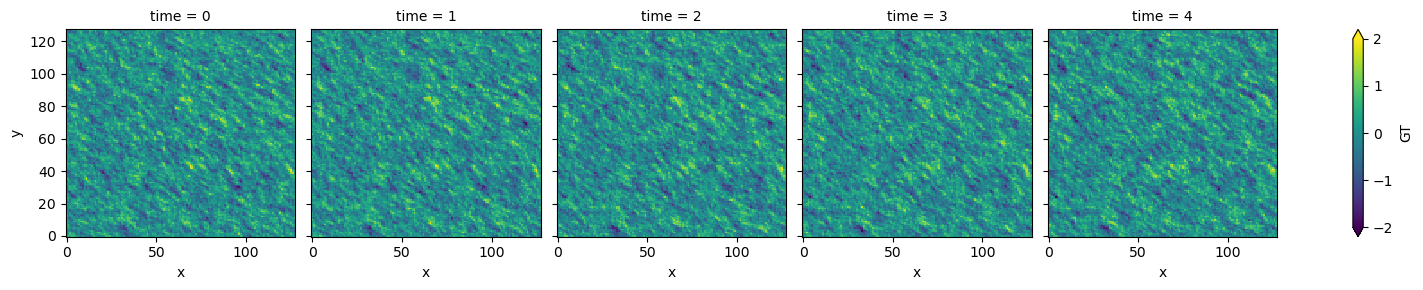

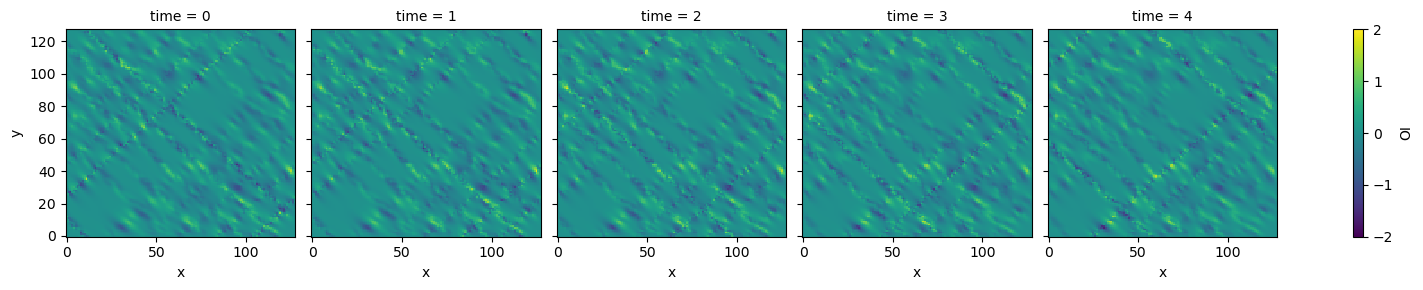

In [16]:
import xarray as xr
# ground truth along the DAW
gt = x[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
# optiml interpolation
out = x_estim
# store outputs as xarray datasets
ds = xr.Dataset(
            data_vars={
                'GT': (('time', 'y', 'x'), np.transpose(gt,(0,2,1))),
                'OI': (('time', 'y', 'x'), np.transpose(out,(0,2,1))),
            },
            coords={
                'time': range(nt),
                'y': range(ny),
                'x': range(nx),
            }
        )
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
plt.show()

# 4. Spatio-temporal conditional simulations

Because OI acts by construction as a smoother of the hidden truth, an option to retrieve the original variability of the gaussian process is to run simulations conditionned by kriging. A simple though elegant solution in traditional geostatistics is to propose a conditional simulation $\mathbf{x}_x$ to be equal to:
\begin{align*}
 \mathbf{x}_c (\mathbf{s}) = \mathbf{x}^\star(\mathbf{s}) + (\mathbf{x}_{nc}(\mathbf{s}) - \mathbf{x}^\star_{nc}(\mathbf{s}))
\end{align*}

## 4.1 Run an alternate simulation

In [17]:
# Initialisation
# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
x2 = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# x2 = [torch.randn(nb_nodes)]
# for i in range(n_iter):
#     x2 = run_simulation(i, x2)
# x2 = torch.stack(x2[1:], dim=0)


## 4.2 Extract this new simulation at the observation points

In [18]:
# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
y2, _ = generate_obs_fast(x2, nx, ny, n_iter)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# y2 = torch.empty(x2.shape)
# y2[:] = np.nan
# for i in range(n_iter):
#     plt.cla()
#     y2, _ = generate_pseudo_obs(i, x, y)


## 4.3 Kriging of the simulation

In [19]:
target_time = 15

# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
x_estim_simulation = space_time_kriging_fast(Qg_csc, chol_Qg, target_time, index_obs, y2, nt, nb_nodes).reshape(nt, nx, ny).cpu().numpy()

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# x_estim_simulation = space_time_kriging(Qg, target_time, index_obs, y2).reshape(nt, nx, ny).cpu().numpy()


## 4.4 Conditional simulation 

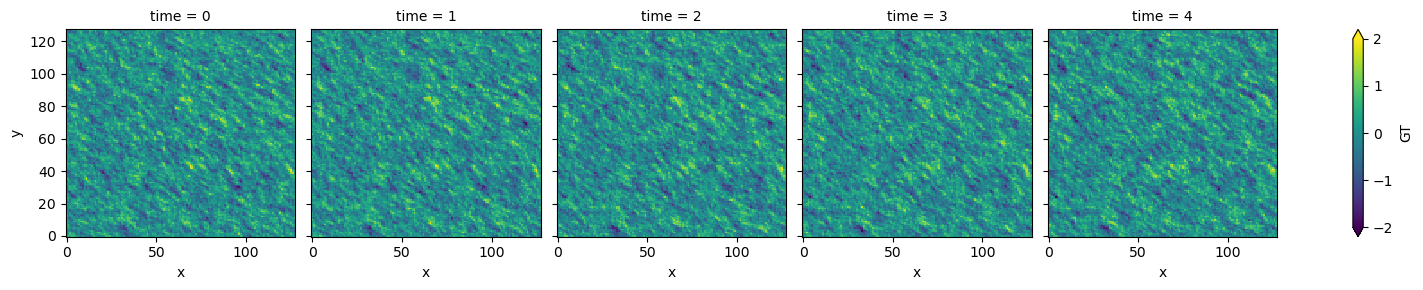

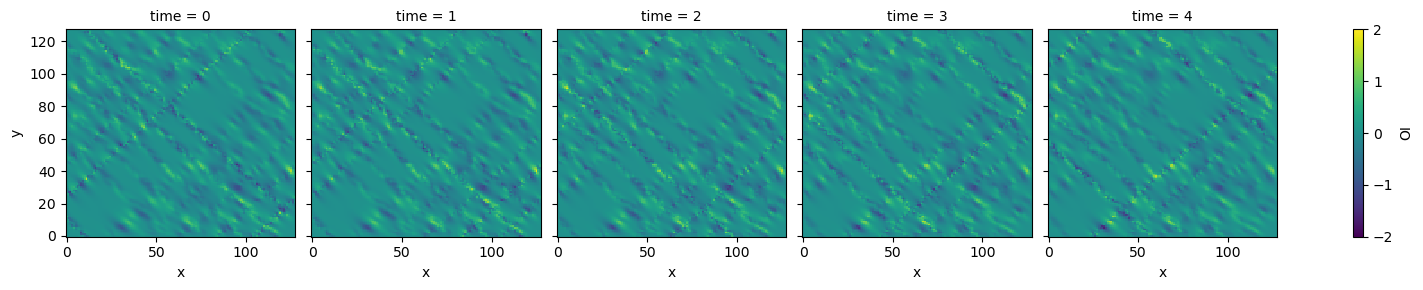

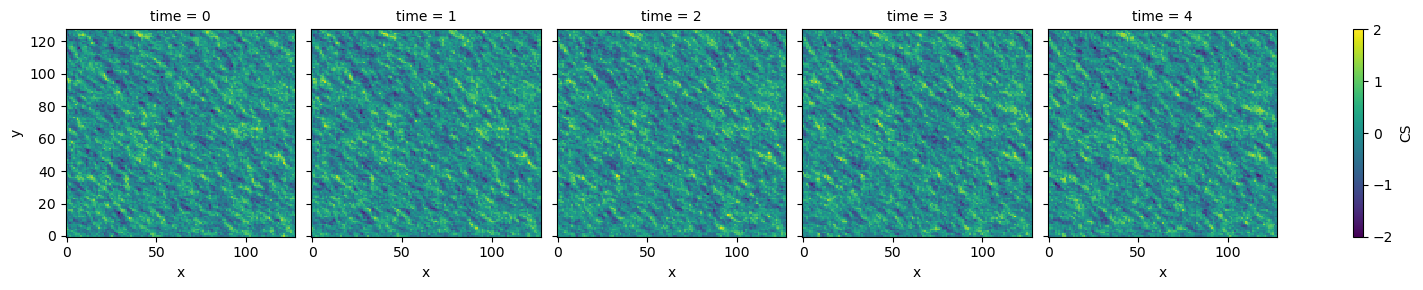

In [20]:
simulation = x2[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
x_cs = x_estim + (simulation-x_estim_simulation)
ds = ds.update({ 'CS': (('time', 'y', 'x'),x_cs)})
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
ds.CS.plot(col='time',vmin=-2,vmax=2)
plt.show()

# 5. Same framework with local anisotropy

Let now introduce some local anisotropies. The underlying idea in this practical session would be to generate some artifical eddies.

\begin{eqnarray*}
(\kappa^2-\nabla \cdot \mathbf{H}(\mathbf{s},t)\nabla)^{\frac{\alpha}{2}}\mathbf{X}(\mathbf{s},t)=\tau\mathbf{Z}(\mathbf{s},t)
\end{eqnarray*}

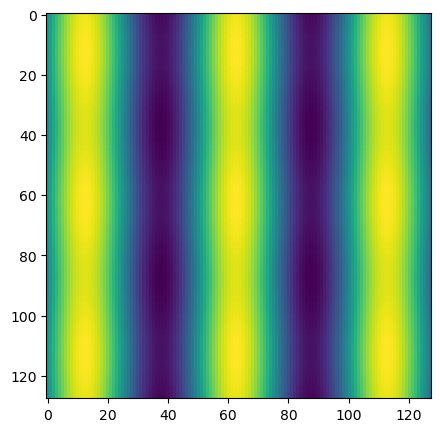

In [6]:
plt.rcParams['figure.figsize'] = [10,5]

def fxy(x,y):
 return( ((2*resolution)/np.pi)*( (3/4)*np.sin(2*np.pi*x/(5*resolution))) + (1/4)*np.sin(2*np.pi*y/(5*resolution) ))

x, y = np.meshgrid(range(nx),range(ny))
res = np.array(fxy(x,y))

plt.imshow(res)
grad = np.gradient(res)
u_ = grad[0]
v_ = grad[1]

def rotate_vector(x1,y1,angle):
  x1_ = x1.flatten()
  y1_ = y1.flatten()
  x2_ = np.cos(angle)*x1_-np.sin(angle)*y1_
  y2_ = np.sin(angle)*x1_+np.cos(angle)*y1_
  return np.c_[x2_,y2_]

u = np.transpose(np.reshape(np.array(rotate_vector(u_,v_,-np.pi/2)[:,0],),(nx,ny)))
v = np.transpose(np.reshape(np.array(rotate_vector(u_,v_,-np.pi/2)[:,1]),(nx,ny)))
plt.show()

In [7]:
def diffusion_tensor(u,v,gamma,beta):
  nb_nodes = u.shape[0]*u.shape[1]
  H = np.zeros((2,2,nb_nodes))
  cpt=0
  for i in range(u.shape[0]):
    for j in range(u.shape[1]):
      vs = np.r_[u[i,j],v[i,j]].reshape((2,1))
      Hs = (gamma*np.eye(2)) + beta*(vs @ vs.T)
      H[:,:,cpt] = Hs
      cpt = cpt+1
  return H

H_ = torch.from_numpy(diffusion_tensor(u,v,1,25)).float()

\begin{eqnarray}
H(\mathbf{s})=\gamma \mathbf{I}_2 + \beta\left[\mathbf{v}(\mathbf{s}) \mathbf{v}(\mathbf{s})^\mathrm{T}\right]
\end{eqnarray}

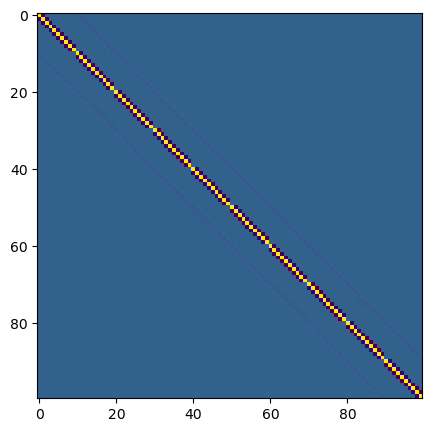

In [9]:
%matplotlib inline

def diff_operator2(nx, ny, dx, dy, H, kappa):

    nb_nodes = nx*ny

    index = torch.arange(0,nb_nodes)
    ## Right neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 0)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k1 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + 1, (-1*H[0,0,index_sel_neighs]/(dx**2)) ))
    ## Left neighbours
    index_sel = torch.where(torch.fmod(index+1,nx) != 1)[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k2 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - 1, (-1*H[0,0,index_sel_neighs]/(dx**2)) ))
    ## Top neighbours
    index_sel = torch.where((index+1) <= (ny-1)*nx )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k3 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx, (-1*H[1,1,index_sel_neighs]/(dx**2)) ))
    ## Bottom neighbours
    index_sel = torch.where((index+1) >= (nx+1) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k4 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx, (-1*H[1,1,index_sel_neighs]/(dx**2)) ))
    ## Top-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k5 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx+1, ((H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Top-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)<= (ny-1)*nx) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k6 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() + nx-1, (-1*(H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Bottom-right neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 0) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k7 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx+1, (-1*(H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Bottom-left neighbours
    index_sel = torch.where( (torch.fmod(index+1,nx) != 1) & ((index+1)>=(nx+1)) )[0]
    N=len(index_sel)
    index_sel_neighs = torch.index_select(index,0,index_sel)
    k8 = torch.stack((index_sel_neighs.float(), index_sel_neighs.float() - nx-1, ((H[0,1,index_sel_neighs]+H[1,0,index_sel_neighs])/(4*dx*dy)) ))
    ## Central point
    N=len(index)
    k9 = torch.stack((index.float(), index.float(), (kappa**2 + 2*(H[0,0,index]/(dx**2) + H[1,1,index]/(dy**2))) ))
    ## Stack all neighbours
    k = torch.cat((k1, k2, k3, k4, k5, k6, k7, k8, k9),dim=1)
    ## Create sparseMatrix
    return(torch.sparse.FloatTensor(k[0:2].long(), k[2], torch.Size([nb_nodes,nb_nodes])))

## Example
A=diff_operator2(10,10,1,1,H=H_,kappa=1/3)
plt.imshow(A.to_dense().numpy())

In [10]:
%matplotlib inline

pow = 2
dt = 1
A=diff_operator2(nx,ny,dx,dy,H=H_,kappa=1./3)
B = A
#B = torch.t(A) @ A
#B=pow_diff_operator(A,pow)
L = Scipy_SolveCholesky.apply(B,dt)
Achol = torch.tensor(np.dot(L.to_dense().numpy(),np.transpose(L.to_dense().numpy())))

/tmp/ipykernel_2502725/3836502537.py:49: UserWarning: torch.sparse.SparseTensor(indices, values, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:641.)
  L = torch.sparse.FloatTensor(torch.LongTensor([Lcoo.row.tolist(), Lcoo.col.tolist()]),


In [3]:

# --- Diagnostic: spectral radius of B and Qg (using power iteration, avoid dense OOM) ---
import torch

def power_iter_sparse(M_sp, n_iter=80):
    """Estimate largest eigenvalue of a sparse matrix via power iteration."""
    n = M_sp.shape[0]
    v = torch.randn(n, device=M_sp.device, dtype=M_sp.dtype)
    v = v / v.norm()
    for _ in range(n_iter):
        v = torch.mv(M_sp, v)
        nrm = v.norm()
        if nrm < 1e-30:
            break
        v = v / nrm
    lam = torch.dot(v, torch.mv(M_sp, v)).item()
    return lam

lam_B = power_iter_sparse(B)

# Build M = I + dt*B as sparse
Id_sp = torch.sparse_coo_tensor(
    torch.arange(nb_nodes).unsqueeze(0).repeat(2, 1),
    torch.ones(nb_nodes, dtype=B.dtype, device=B.device),
    (nb_nodes, nb_nodes)
).coalesce()
M_sp = (Id_sp + dt * B).coalesce()

lam_M = power_iter_sparse(M_sp)

print(f"λ_max(B)           = {lam_B:.3f}")
print(f"dt                 = {dt}")
print(f"λ_max(M = I+dt·B)  = {lam_M:.3f}")
print(f"λ_max(M²)          ≈ {lam_M**2:.1f}")
print(f"Qg diagonal block max ≈ λ_max(M²)+1 ≈ {lam_M**2 + 1:.1f}")
print(f"Qg off-diagonal   max ≈ λ_max(M)   ≈ {lam_M:.1f}")
print(f"Approx cond(Qg)       ≈ (λ_max(M))⁴ ≈ {lam_M**4:.2e}")


NameError: name 'B' is not defined

In [26]:
# Initialisation
# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
# Reconstruire les matrices denses depuis le nouveau L (anisotrope)
L_d, L_dT = build_simulation_solver(L)
x = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# x = [torch.randn(nb_nodes)]
# filenames = []
# for i in range(n_iter):
#     plt.cla()
#     x = run_simulation(i, x)
#     filename = f'{i}.png'
#     filenames.append(filename)
#     plt.savefig(filename)
#     plt.close()
#
# if os.path.exists('mysimu2.gif'):
#     os.remove('mysimu2.gif')
# with imageio.get_writer('mysimu2.gif', mode='I') as writer:
#     for filename in filenames:
#         image = imageio.imread(filename)
#         writer.append_data(image)
# for filename in set(filenames):
#     os.remove(filename)
#
# x = torch.stack(x[1:], dim=0)


In [27]:
from IPython.display import Image
Image(url='mysimu2.gif') 

In [27]:
# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
y, index_obs = generate_obs_fast(x, nx, ny, n_iter)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# y = torch.empty(x.shape)
# y[:] = np.nan
# index_obs = []
# filenames = []
# for i in range(n_iter):
#     plt.cla()
#     y, index_obs = generate_pseudo_obs(i, x, y)
#     filename = f'{i}.png'
#     filenames.append(filename)
#     plt.savefig(filename)
#     plt.close()
#
# if os.path.exists('mydata2.gif'):
#     os.remove('mydata2.gif')
# with imageio.get_writer('mydata2.gif', mode='I') as writer:
#     for filename in filenames:
#         image = imageio.imread(filename)
#         writer.append_data(image)
# for filename in set(filenames):
#     os.remove(filename)


In [29]:
from IPython.display import Image
Image(url='mydata2.gif') 

λ_max(B) = 43.04  →  normalising B by 1/43.04
λ_max(M = I + dt·B_norm) ≈ 2.00


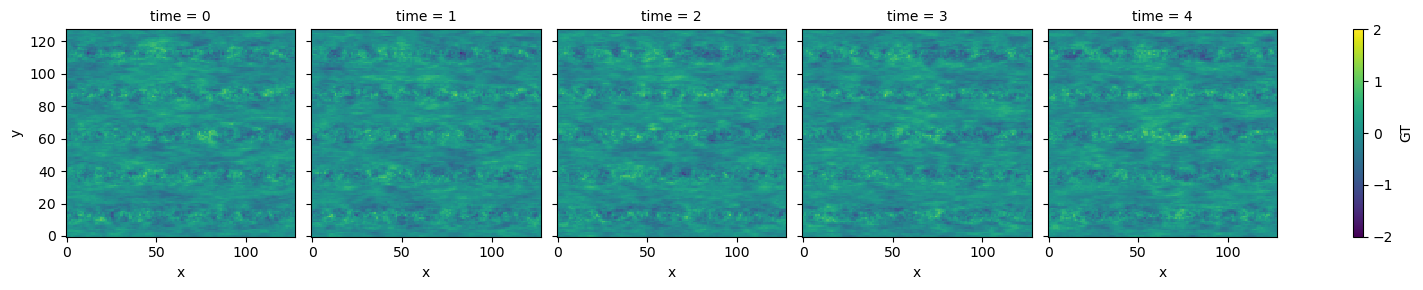

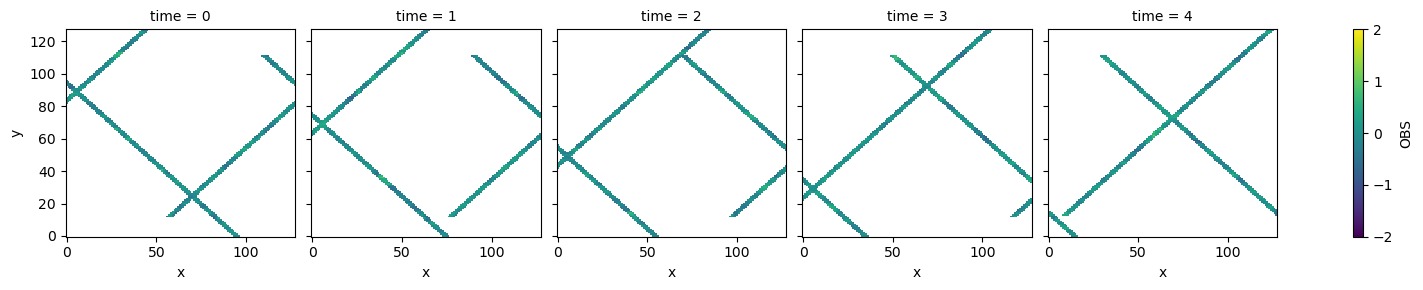

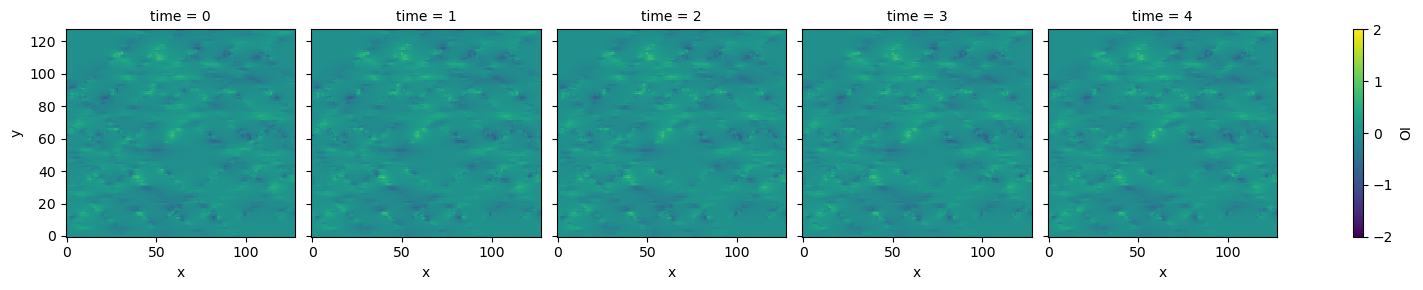

In [28]:

# Normalise B so that M = I + dt*B_norm has eigenvalues of order 1.
# Without normalisation, λ_max(B = A^T A) ≈ λ_max(A)² which can reach ~1855
# with β=25 anisotropy, making M² ill-conditioned (cond(Qg) ~ 10^13 → blow-up).
# Dividing B by its spectral radius keeps M well-conditioned while preserving
# the covariance structure (scale is absorbed into the marginal variance).
lam_B_max = power_iter_sparse(B)
B_norm = (1.0 / lam_B_max) * B
print(f"λ_max(B) = {lam_B_max:.2f}  →  normalising B by 1/{lam_B_max:.2f}")
print(f"λ_max(M = I + dt·B_norm) ≈ {1 + dt/lam_B_max * lam_B_max:.2f}")

Qg = global_precision_matrix(B_norm, dt)
Qg = 0.5 * (Qg + Qg.transpose(0, 1))

target_time = 215

# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
# Reconstruire le solver cholmod depuis le nouveau Qg (anisotrope normalisé)
Qg_csc, chol_Qg = build_fast_solver(Qg)
x_estim = space_time_kriging_fast(Qg_csc, chol_Qg, target_time, index_obs, y, nt, nb_nodes).reshape(nt, nx, ny).cpu().numpy()

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# x_estim = space_time_kriging(Qg, target_time, index_obs, x).reshape(nt, nx, ny).cpu().numpy()

gt = x[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
obs = y[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
ds = xr.Dataset(
            data_vars={
                'GT': (('time', 'y', 'x'), gt),
                'OBS': (('time', 'y', 'x'), obs),
                'OI': (('time', 'y', 'x'), x_estim),
            },
            coords={
                'time': range(nt),
                'y': range(ny),
                'x': range(nx),
            }
        )
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OBS.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
plt.show()


In [29]:
# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
# Nouvelle simulation
x2 = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)
# Extraction aux points d'observation
y2, _ = generate_obs_fast(x2, nx, ny, n_iter)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# New simulation
# x2 = [torch.randn(nb_nodes)]
# for i in range(n_iter):
#     x2 = run_simulation(i, x2)
# x2 = torch.stack(x2[1:], dim=0)
# Extract simulation at observation points
# y2 = torch.empty(x2.shape)
# y2[:] = np.nan
# for i in range(n_iter):
#     plt.cla()
#     y2, _ = generate_pseudo_obs(i, x2, y2)


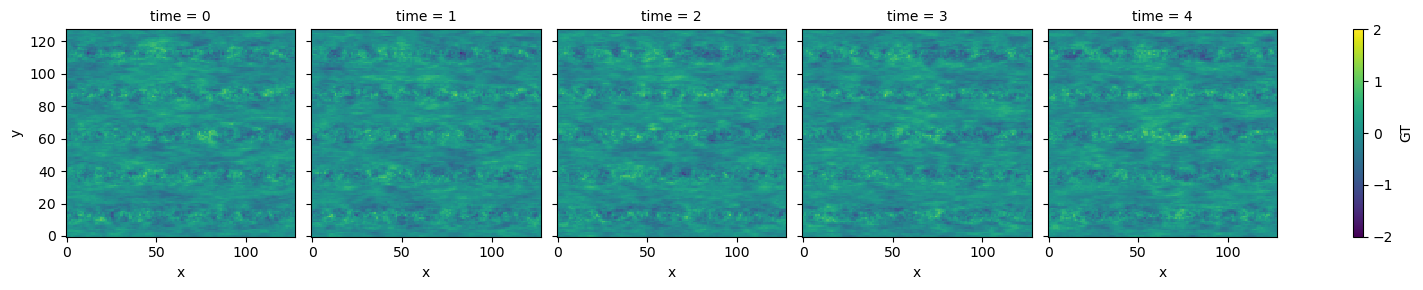

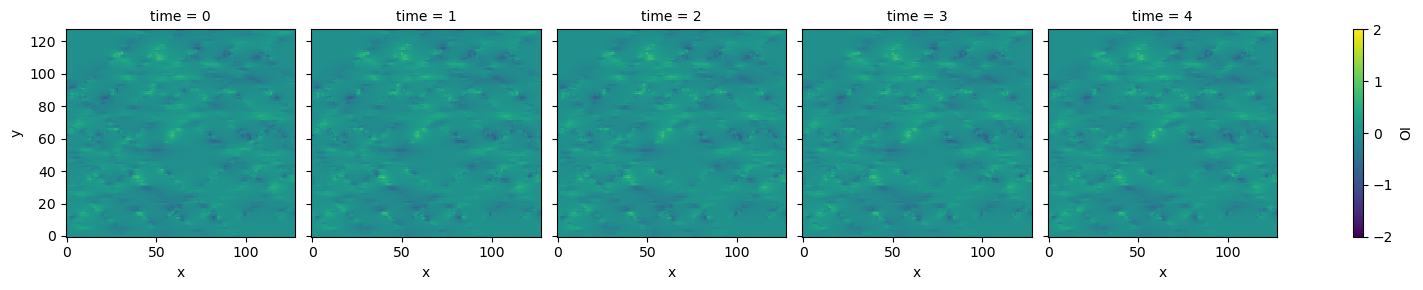

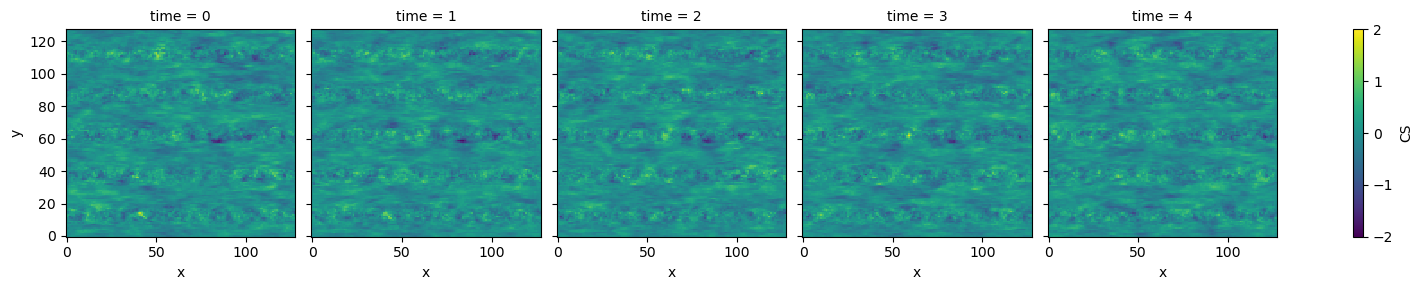

In [30]:
target_time = 215

# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
# Kriging of the simulation
x_estim_simulation = space_time_kriging_fast(Qg_csc, chol_Qg, target_time, index_obs, y2, nt, nb_nodes).reshape(nt, nx, ny).cpu().numpy()

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# x_estim_simulation = space_time_kriging(Qg, target_time, index_obs, y2).reshape(nt, nx, ny).cpu().numpy()

# Conditional simulation
simulation = x2[np.arange(target_time-2,target_time+3)].reshape(nt,nx,ny).cpu().numpy()
x_cs = x_estim + (simulation-x_estim_simulation)
ds = ds.update({ 'CS': (('time', 'y', 'x'),x_cs)})
ds.GT.plot(col='time',vmin=-2,vmax=2)
ds.OI.plot(col='time',vmin=-2,vmax=2)
ds.CS.plot(col='time',vmin=-2,vmax=2)
plt.show()


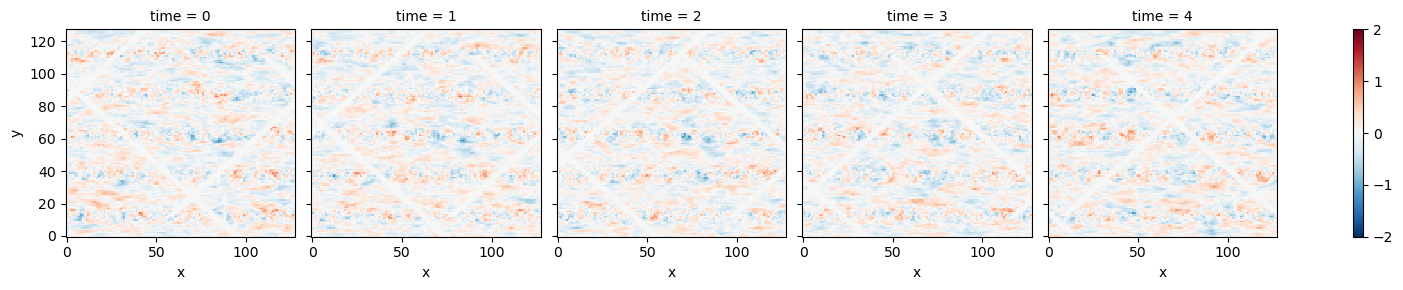

In [31]:
(ds.CS -ds.OI).plot(col='time',vmin=-2,vmax=2,cmap='RdBu_r')


# 6. Run the OI baseline

Here, let run the OI baseline on the entire dataset, from $t$=0 to $t$=500. Then, let start by generating a new simulation with 500 time step and additional pseudo-obs before running the associated oi

In [32]:
# ── VERSION RAPIDE ────────────────────────────────────────────────────────────
# new simulation with n_iter = 300
n_iter = 300
L_d, L_dT = build_simulation_solver(L)
x = run_simulation_fast(n_iter, L_d, L_dT, dt=dt, dx=dx, dy=dy, nb_nodes=nb_nodes)
# Extract simulation at observation points
y, index_obs = generate_obs_fast(x, nx, ny, n_iter)
# Run the OI (fast: cholmod + vectorised time loop)
Qg_csc, chol_Qg = build_fast_solver(Qg)
oi = run_oi_fast(Qg, Qg_csc, chol_Qg, n_iter, index_obs, y, nt).reshape(n_iter, nx, ny)

# ── VERSION LENTE (commentée) ─────────────────────────────────────────────────
# n_iter = 300
# x = [torch.randn(nb_nodes)]
# for i in range(n_iter):
#     x = run_simulation(i, x)
# x = torch.stack(x[1:], dim=0)
# # Extract simulation at observation points
# y = torch.empty(x.shape)
# y[:] = np.nan
# index_obs = []
# for i in range(n_iter):
#     plt.cla()
#     y, index_obs = generate_pseudo_obs(i, x, y)
# # run the oi
# oi = np.empty((n_iter, nx, ny))
# for i in range(n_iter):
#     print(i)
#     if (i >= 2) and (i < n_iter - 2):
#         oi[i] = space_time_kriging(Qg, i, index_obs, y).reshape(nt, nx, ny).cpu().numpy()[int(nt/2)]


  t=  50/300  36.1s écoulé  1.4 pas/s  ETA 184s
  t= 100/300  76.6s écoulé  1.3 pas/s  ETA 155s
  t= 100/300  76.6s écoulé  1.3 pas/s  ETA 155s
  t= 150/300  115.9s écoulé  1.3 pas/s  ETA 117s
  t= 150/300  115.9s écoulé  1.3 pas/s  ETA 117s
  t= 200/300  156.9s écoulé  1.3 pas/s  ETA 79s
  t= 200/300  156.9s écoulé  1.3 pas/s  ETA 79s
  t= 250/300  193.3s écoulé  1.3 pas/s  ETA 39s
  t= 250/300  193.3s écoulé  1.3 pas/s  ETA 39s
Done — 300 pas en 218.7s (1.4 pas/s)
Done — 300 pas en 218.7s (1.4 pas/s)


# 7. Save the dataset

In [33]:
ds = xr.Dataset(
    data_vars=dict(
        x = (["time", "lat", "lon"], x.reshape((n_iter,nx,ny))),
        y = (["time", "lat", "lon"], y.reshape((n_iter,nx,ny))),
        OI = (["time", "lat", "lon"], oi),
        H11 = (["lat", "lon"], H_[0,0,:].reshape(nx,ny)),
        H22 = (["lat", "lon"], H_[1,1,:].reshape(nx,ny)),
        H12 = (["lat", "lon"], H_[0,1,:].reshape(nx,ny)),
        Time = (["time"], np.arange(n_iter)),
        longitude = (["lon"], np.arange(0,nx)),
        latitude = (["lat"], np.arange(0,ny))
    ),
    coords=dict(
        lon = np.arange(0,nx),
        lat = np.arange(0,ny),
        time = np.arange(n_iter)
    ),
    attrs=dict(description="SPDE-based diffusion GP"),
)

In [34]:
ds

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB -0.1977 -0.1446 ... 0.09631 0.03616
    y          (time, lat, lon) float32 20MB nan nan nan nan ... nan nan nan nan
    OI         (time, lat, lon) float64 39MB nan nan nan nan ... nan nan nan nan
    H11        (lat, lon) float32 66kB 9.953 9.953 9.953 ... 9.673 9.673 9.673
    H22        (lat, lon) float32 66kB 1.025 1.024 1.023 ... 1.025 1.024 1.024
    H12        (lat, lon) float32 66kB -0.4688 -0.4651 ... -0.4577 -0.4541
    Time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
    longitude  (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
    latitude   (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
Attributes:
    description:  SPDE-based diffusion GP

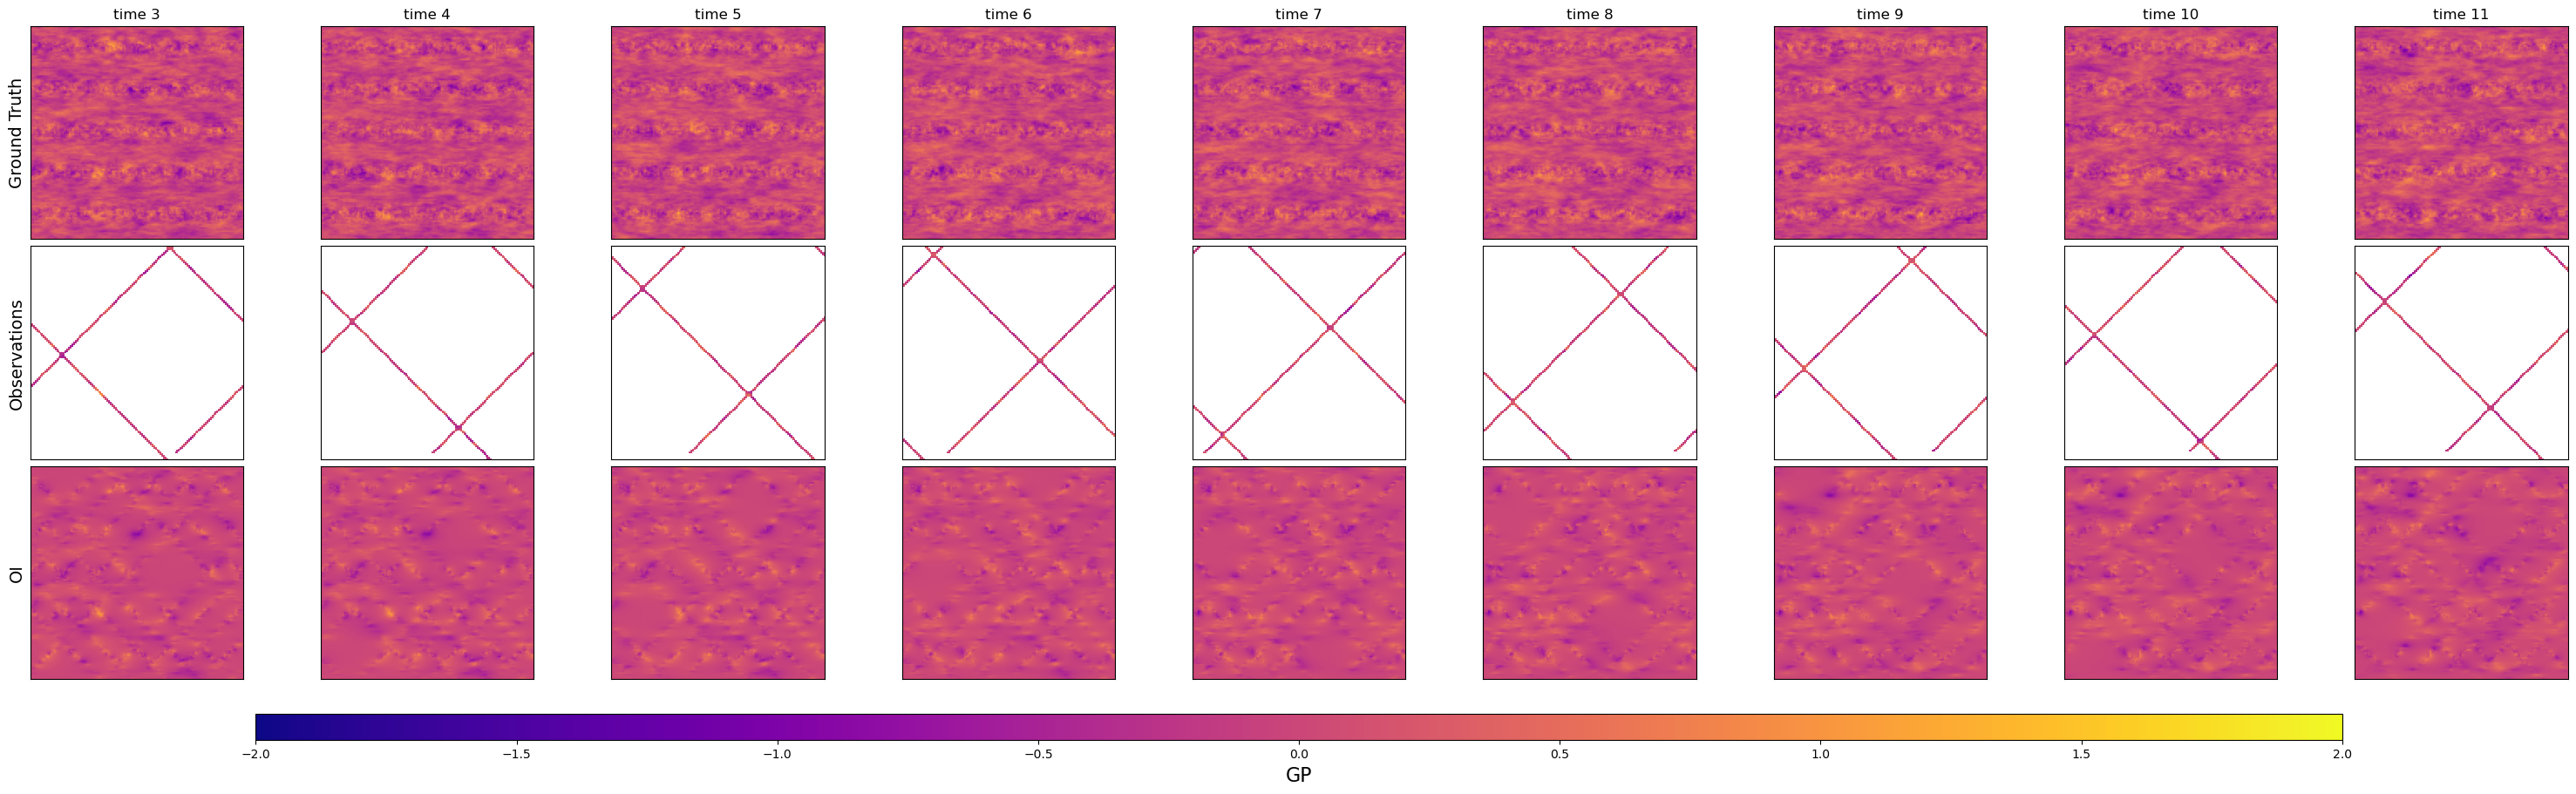

In [35]:
# Combine ds.x, ds.y, and ds.OI into a single plot with one colorbar
fig, axes = plt.subplots(3, 9, figsize=(30, 9), constrained_layout=True)

time_slice = slice(3, 12)
data_x = ds.x.isel(time=time_slice)
data_y = ds.y.isel(time=time_slice)
data_oi = ds.OI.isel(time=time_slice)

# Row 0: Ground Truth (x)
for time_idx in range(9):
    ax = axes[0, time_idx]
    im = ax.imshow(data_x[time_idx].values, vmin=-2, vmax=2, cmap=plt.cm.plasma)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('Ground Truth', fontsize=14)
    ax.set_title(f'time {time_idx + 3}', fontsize=12)

# Row 1: Observations (y)
for time_idx in range(9):
    ax = axes[1, time_idx]
    im = ax.imshow(data_y[time_idx].values, vmin=-2, vmax=2, cmap=plt.cm.plasma)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('Observations', fontsize=14)

# Row 2: OI
for time_idx in range(9):
    ax = axes[2, time_idx]
    im = ax.imshow(data_oi[time_idx].values, vmin=-2, vmax=2, cmap=plt.cm.plasma)
    ax.set_xticks([])
    ax.set_yticks([])
    if time_idx == 0:
        ax.set_ylabel('OI', fontsize=14)

# Add a single colorbar below all subplots
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, aspect=80, shrink=0.8)
cbar.set_label('GP', fontsize=16)

plt.savefig("../../4dvarnet-starter/figs/combined_plot_gp_data_Notebook.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
ds.to_netcdf('SPDE_diffusion_dataset_'+str(pow)+'.nc')